<a href="https://colab.research.google.com/github/Huii0529/MSc_STQD6014_DataScience_Project_2/blob/main/STQD6014_PROJECT2_P167347.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1.0 Introduction**

## **An Analysis of Credit Card Ownership Trends by Gender Across Countries (2011–2022)**

Credit card ownership is an important indicator of financial inclusion, reflecting individuals' access to formal financial services and participation in the digital economy. As economies become increasingly cashless, access to credit cards facilitates online transactions, improves financial flexibility, and promotes economic participation. However, disparities in credit card ownership continue to exist across countries and between demographic groups, particularly between males and females. This study analyses global credit card ownership trends from 2011 to 2022 using data obtained from the World Bank Data360 database. The analysis focuses on comparing ownership patterns by gender, identifying countries with the highest levels of credit card ownership, and examining how ownership has evolved over time. The findings provide valuable insights into global financial inclusion and the remaining gender gap in access to financial services.

Datasets Source:
1. https://data360.worldbank.org/en/indicator/WB_GS_FIN7_T_A

## **1.1 Problem Statements:**

1. Is there a significant difference in credit card ownership between males and females?
2. How has global credit card ownership changed between 2011 and 2022?
3. Which countries recorded the highest levels of credit card ownership in 2021?
4. What is the overall distribution of credit card ownership across countries?

## **1.2 Hypothesis Testing:**

**H₀:** There is no significant difference in average credit card ownership between males and females.

**H₁:** There is a significant difference in average credit card ownership between males and females.

# **2.0 Data Collection**

Three datasets were retrieved from the World Bank Group (WB).

In [ ]:
# Import Libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Import dataset
from google.colab import files
files.upload()

Saving WB_GS_FIN7_T_A_WIDEF.csv to WB_GS_FIN7_T_A_WIDEF.csv


{'WB_GS_FIN7_T_A_WIDEF.csv': b'FREQ,FREQ_LABEL,REF_AREA,REF_AREA_LABEL,INDICATOR,INDICATOR_LABEL,SEX,SEX_LABEL,2011,2014,2017,2021,2022\r\nA,Annual,AFG,Afghanistan,WB_GS_FIN7_T_A,Credit card ownership (% age 15+),F,Female,0.51,0.29,0.34,0,\r\nA,Annual,AFG,Afghanistan,WB_GS_FIN7_T_A,Credit card ownership (% age 15+),M,Male,1.15,2.43,1.78,0,\r\nA,Annual,AFG,Afghanistan,WB_GS_FIN7_T_A,Credit card ownership (% age 15+),_T,Total,0.83,1.39,1.06,0,\r\nA,Annual,AGO,Angola,WB_GS_FIN7_T_A,Credit card ownership (% age 15+),F,Female,17.11,3.15,,,\r\nA,Annual,AGO,Angola,WB_GS_FIN7_T_A,Credit card ownership (% age 15+),M,Male,13.85,5.65,,,\r\nA,Annual,AGO,Angola,WB_GS_FIN7_T_A,Credit card ownership (% age 15+),_T,Total,15.49,4.41,,,\r\nA,Annual,ALB,Albania,WB_GS_FIN7_T_A,Credit card ownership (% age 15+),F,Female,7.81,5.04,5.61,4.06,\r\nA,Annual,ALB,Albania,WB_GS_FIN7_T_A,Credit card ownership (% age 15+),M,Male,13.27,6.3,10.57,5.87,\r\nA,Annual,ALB,Albania,WB_GS_FIN7_T_A,Credit card ownership (% ag

In [ ]:
df = pd.read_table('/content/WB_GS_FIN7_T_A_WIDEF.csv', sep = ',')
df

,FREQ,FREQ_LABEL,REF_AREA,REF_AREA_LABEL,INDICATOR,INDICATOR_LABEL,SEX,SEX_LABEL,2011,2014,2017,2021,2022
0,A,Annual,AFG,Afghanistan,WB_GS_FIN7_T_A,Credit card ownership (% age 15+),F,Female,0.51,0.29,0.34,0.00,NaN
1,A,Annual,AFG,Afghanistan,WB_GS_FIN7_T_A,Credit card ownership (% age 15+),M,Male,1.15,2.43,1.78,0.00,NaN
2,A,Annual,AFG,Afghanistan,WB_GS_FIN7_T_A,Credit card ownership (% age 15+),_T,Total,0.83,1.39,1.06,0.00,NaN
3,A,Annual,AGO,Angola,WB_GS_FIN7_T_A,Credit card ownership (% age 15+),F,Female,17.11,3.15,NaN,NaN,NaN
4,A,Annual,AGO,Angola,WB_GS_FIN7_T_A,Credit card ownership (% age 15+),M,Male,13.85,5.65,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
544,A,Annual,ZMB,Zambia,WB_GS_FIN7_T_A,Credit card ownership (% age 15+),M,Male,3.71,1.54,5.72,1.98,NaN
545,A,Annual,ZMB,Zambia,WB_GS_FIN7_T_A,Credit card ownership (% age 15+),_T,Total,3.72,1.88,4.27,2.03,NaN
546,A,Annual,ZWE,Zimbabwe,WB_GS_FIN7_T_A,Credit card ownership (% age 15+),F,Female,5.59,1.46,0.87,0.45,NaN
547,A,Annual,ZWE,Zimbabwe,WB_GS_FIN7_T_A,Credit card ownership (% age 15+),M,Male,7.46,2.21,1.86,0.54,NaN


## **2.1 Data Cleaning**

In [ ]:
# Copy dataset
df = df.copy()

# Clean column names
df.columns = df.columns.str.strip()

# Rename key columns for easier use
df = df.rename(columns={
    "REF_AREA_LABEL": "Country",
    "SEX_LABEL": "Sex"
})

# Keep only needed columns
df = df[[
    "Country",
    "Sex",
    "2011",
    "2014",
    "2017",
    "2021",
    "2022"
]]

# Convert to long format (IMPORTANT STEP)
df_melted = df.melt(
    id_vars=["Country", "Sex"],
    value_vars=["2011", "2014", "2017", "2021", "2022"],
    var_name="Year",
    value_name="Ownership_Percentage"
)

# Convert Year to integer
df_melted["Year"] = df_melted["Year"].astype(int)

# Remove missing values
df_melted = df_melted.dropna(subset=["Ownership_Percentage"])

# Final check
print(df_melted.head())
print(df_melted.info())

       Country     Sex  Year  Ownership_Percentage
0  Afghanistan  Female  2011                  0.51
1  Afghanistan    Male  2011                  1.15
2  Afghanistan   Total  2011                  0.83
3       Angola  Female  2011                 17.11
4       Angola    Male  2011                 13.85
<class 'pandas.core.frame.DataFrame'>
Index: 1959 entries, 0 to 2735
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Country               1959 non-null   object 
 1   Sex                   1959 non-null   object 
 2   Year                  1959 non-null   int64  
 3   Ownership_Percentage  1959 non-null   float64
dtypes: float64(1), int64(1), object(2)
memory usage: 76.5+ KB
None


In [ ]:
# Dataset for Gender Analysis
df_gender = df_melted[df_melted["Sex"] != "Total"]

In [ ]:
# Dataset for Overall Trend Analysis
df_total = df_melted[df_melted["Sex"] == "Total"]

## **3.0 Data Visualization and Analysis**

We will now create several visualizations to explore the credit card ownership trends, gender differences, and country-wise variations using our cleaned dataset.

### **3.1 Gender Trend of Credit Card Ownership Over Time**


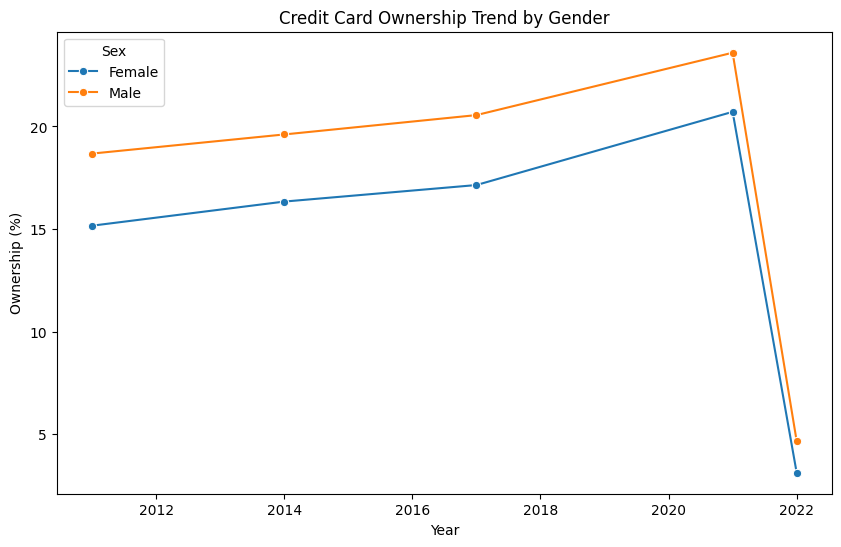

In [ ]:
# Gender Trend Over Time

gender_trend = df_gender.groupby(["Year", "Sex"])["Ownership_Percentage"].mean().reset_index()

plt.figure(figsize=(10,6))
sns.lineplot(data=gender_trend, x="Year", y="Ownership_Percentage", hue="Sex", marker="o")

plt.title("Credit Card Ownership Trend by Gender")
plt.ylabel("Ownership (%)")
plt.show()

This plot shows the trend of average credit card ownership between males and females over time, where both groups generally follow a similar pattern across the observed years. At the beginning of the period, males exhibit a slightly higher ownership rate (around 19%) compared to females, indicating a modest but consistent gender gap in financial access. Despite this difference in level, both genders move in a closely aligned trajectory, suggesting that the overall trend in credit card ownership is influenced more by broader economic and structural factors than by gender alone. A noticeable decline appears in 2022; however, this is likely due to incomplete or missing data rather than a genuine reduction in ownership. Overall, the results indicate that while a small gender gap persists, the similarity in trends suggests relatively comparable changes in financial inclusion for both males and females over time.

### **3.2 Overall Trend (Total population)**

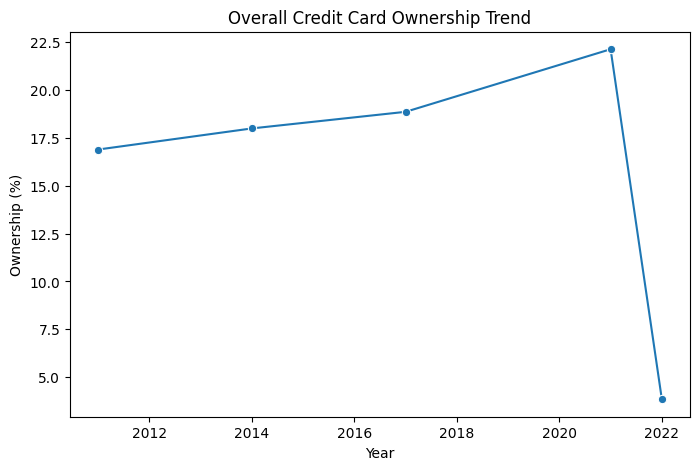

In [ ]:
# Overall Trend
overall_trend = df_total.groupby("Year")["Ownership_Percentage"].mean().reset_index()

plt.figure(figsize=(8,5))
sns.lineplot(data=overall_trend, x="Year", y="Ownership_Percentage", marker="o")

plt.title("Overall Credit Card Ownership Trend")
plt.ylabel("Ownership (%)")
plt.show()

The overall trend of credit card ownership for the total population shows a gradual increase from 2012 to 2021, reaching its highest recorded level of approximately 22.5% in 2021. This upward trend suggests a steady improvement in financial inclusion and increased access to credit facilities over time. However, a sharp decline is observed in 2022, which is likely not a reflection of a real economic downturn but rather the result of incomplete or missing data for that year. Additionally, external factors such as disruptions caused by the COVID-19 pandemic may have influenced data collection and financial behavior during this period, contributing to irregularities in the dataset. Overall, the trend indicates long-term growth in credit card ownership despite short-term fluctuations caused by data limitations.

### **3.3 Country Comparison (2021)**

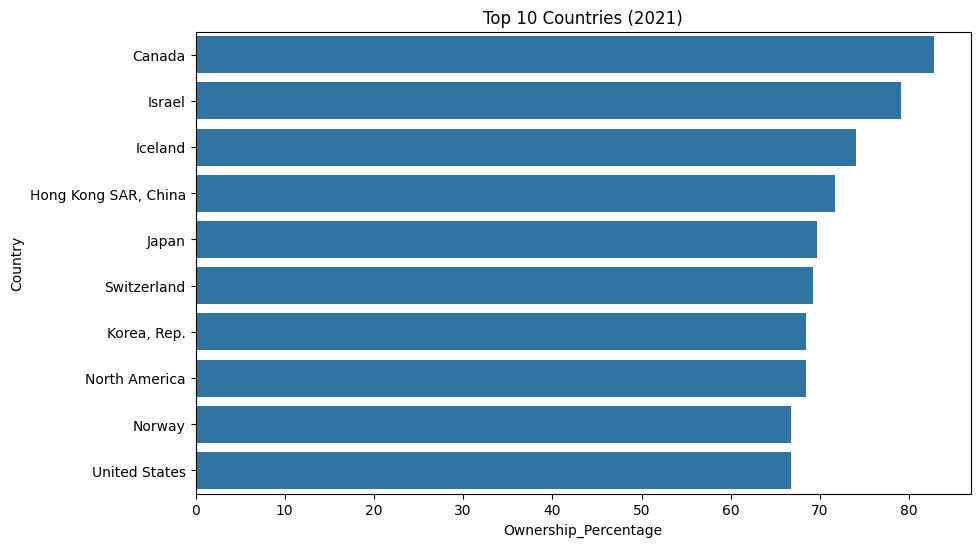

In [ ]:
# Country Comparison (2021)
latest = df_total[df_total["Year"] == 2021]

top_countries = latest.sort_values("Ownership_Percentage", ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(data=top_countries, x="Ownership_Percentage", y="Country")

plt.title("Top 10 Countries (2021)")
plt.show()

The country comparison for 2021 highlights significant variation in credit card ownership across nations, with Canada recording the highest level at approximately 80%, followed closely by Israel at 78% and Iceland at 73%. These results indicate that credit card penetration is substantially higher in developed economies with well-established financial systems and strong digital banking infrastructure. The year 2021 is selected for analysis because it represents a relatively complete dataset compared to later years, while also reflecting a period where digital financial transactions became increasingly important during the COVID-19 pandemic. During this time, the rise of e-commerce, online shopping, and contactless payments likely accelerated the use of credit and debit cards, making 2021 a particularly relevant year for examining modern financial behaviour. Overall, the findings suggest that both economic development and digital adoption play key roles in shaping credit card ownership levels across countries.

### **3.4 Distribution by Gender**

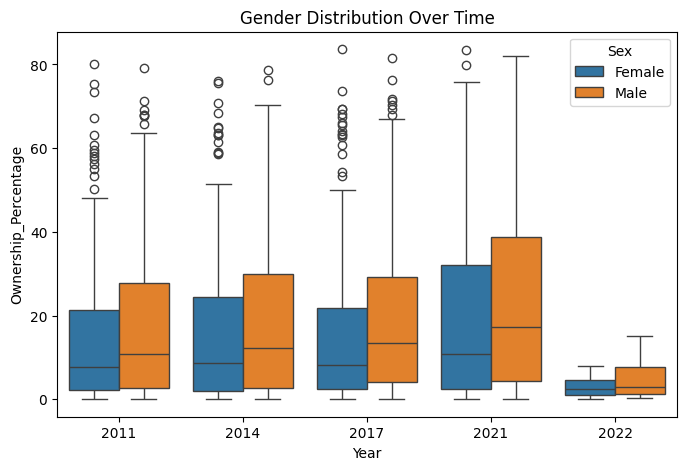

In [ ]:
# Distribution by Gender
plt.figure(figsize=(8,5))
sns.boxplot(data=df_gender, x="Year", y="Ownership_Percentage", hue="Sex")

plt.title("Gender Distribution Over Time")
plt.show()

The box plot illustrates the distribution of credit card ownership percentages by gender across the observed years, showing that males consistently exhibit slightly higher ownership levels than females over time. This suggests a persistent but relatively moderate gender gap in financial access. The distribution also reveals the presence of several outliers in specific years, particularly 2011, 2014, 2017, and 2021, indicating that certain countries deviate significantly from the global pattern. These outliers reflect substantial differences in financial development and access to credit across economies. Overall, while gender differences are observable, the variation between countries is more pronounced, highlighting that geographical and economic factors may play a larger role than gender alone in shaping credit card ownership patterns.

### **3.5 Histogram (Distribution shape)**

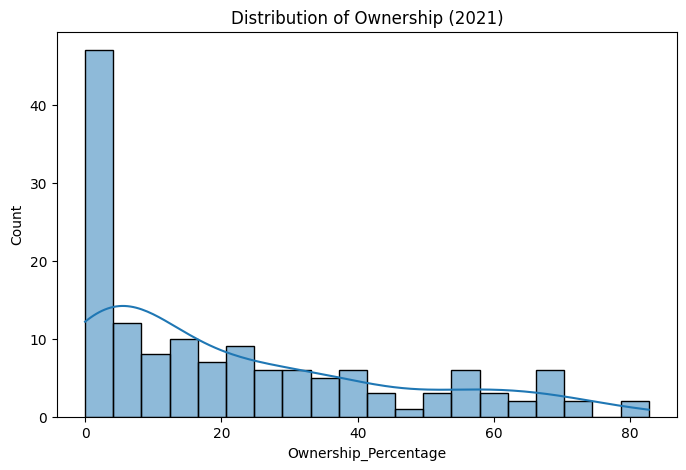

In [ ]:
# Distribution Shape
plt.figure(figsize=(8,5))

sns.histplot(
    df_total[df_total["Year"] == 2021]["Ownership_Percentage"],
    bins=20,
    kde=True
)

plt.title("Distribution of Ownership (2021)")
plt.show()

This histogram shows the distribution of credit card ownership percentages across countries in 2021, and its main purpose is to illustrate how ownership levels are spread globally rather than focusing on a single average value.

The graph is strongly right-skewed, meaning that most countries are clustered at the lower end of ownership (around 0% to 20%). This indicates that in many countries, credit card penetration is still relatively low. As the ownership percentage increases, the number of countries gradually decreases, showing that fewer countries achieve moderate to high levels of credit card adoption. A small number of countries fall into the high-ownership range (above 50% and up to around 80%), representing more financially developed economies.

The smooth KDE curve reinforces this pattern by showing a clear concentration of countries at low ownership levels with a long tail toward higher values. Overall, this plot highlights significant global inequality in financial access, demonstrating that while a few countries have very high credit card usage, the majority remain at low levels of adoption.

### **3.6 Average Credit Card Ownership by Gender (Overall)**

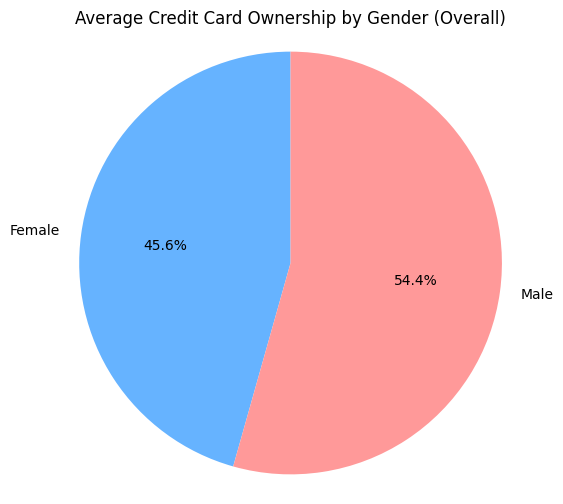

In [ ]:
# Use only Male and Female (exclude Total)
gender_avg = df_melted[df_melted["Sex"] != "Total"] \
    .groupby("Sex")["Ownership_Percentage"].mean()

plt.figure(figsize=(6,6))

plt.pie(
    gender_avg,
    labels=gender_avg.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#66b3ff", "#ff9999"]
)

plt.title("Average Credit Card Ownership by Gender (Overall)")
plt.axis("equal")

plt.show()

The pie chart illustrates the overall average credit card ownership by gender across all countries included in the dataset. The results show that males account for 54.4% of total credit card ownership, while females account for 45.6%, indicating a moderate gender gap in access to credit card services. Although the difference is relatively small, it suggests that men continue to have slightly greater participation in formal financial systems than women. This finding is consistent with the World Bank Global Findex Database, which reported that women are generally less likely than men to access formal financial services, particularly in low- and middle-income economies, due to differences in income, employment opportunities, financial literacy, and access to banking services (Demirgüç-Kunt et al., 2022). Nevertheless, the relatively narrow gap observed in this study suggests that global efforts to improve financial inclusion have contributed to reducing gender disparities in recent years, although further initiatives are still required to achieve equal access to financial products and services.

# **4.0 Suggestions and Future Work**

Based on the findings of this study, governments and financial institutions should continue strengthening financial inclusion initiatives that specifically target women, particularly in developing economies where gender disparities in access to formal financial services remain evident. Improving financial literacy, expanding access to banking services, and promoting women's participation in the formal financial system can help reduce the existing gender gap in credit card ownership. The OECD (2025) emphasises that improving digital financial literacy is essential for enabling individuals to use digital payment services safely and confidently, while targeted financial education programmes can help reduce inequalities in financial inclusion.

Financial institutions should also continue investing in digital financial services by expanding secure online banking platforms, contactless payment technologies, and digital payment incentives. According to the OECD (2021), the rapid expansion of digital payment systems has improved financial inclusion by providing greater access to formal financial services, particularly for underserved populations and women during and after the COVID-19 pandemic.

For future research, additional socioeconomic variables, such as income level, educational attainment, employment status, age group, and gross domestic product (GDP) per capita, should be incorporated to provide a more comprehensive understanding of the factors influencing credit card ownership. Previous research has shown that gender, income, and education are significant determinants of financial inclusion, and statistically significant differences exist between men and women in credit card ownership across countries (Antonijević et al., 2022). Future studies may also classify countries according to income level or geographical region and apply inferential statistical techniques, such as independent-samples t-tests, correlation analysis, or multiple regression analysis, to identify the key determinants of credit card ownership and provide stronger empirical evidence for policy recommendations.

# **5.0 Conclusion**

This study analysed global credit card ownership trends by gender from 2011 to 2022 using data from the World Bank Data360 database. The findings indicate that credit card ownership generally increased over time, reaching its highest average level in 2021 before declining in 2022 due to incomplete data coverage. Male ownership remained consistently higher than female ownership throughout the study period, accounting for an overall average of 54.4% compared with 45.6% for females. In addition, substantial differences were observed across countries, with developed economies such as Canada, Israel, and Iceland recording the highest ownership rates in 2021. The distribution analysis further revealed that most countries continue to exhibit relatively low credit card ownership, while only a small number of countries demonstrate high levels of financial inclusion.

Overall, the findings suggest that although global access to credit card services has improved over the past decade, disparities in ownership persist across genders and countries. The relatively small but consistent gender gap highlights the importance of continuing efforts to promote equitable access to formal financial services, while the wide variation between countries underscores the influence of economic development and digital financial infrastructure on credit card adoption. These findings provide useful insights for policymakers and financial institutions in designing strategies to strengthen financial inclusion and encourage wider participation in the formal financial system.

# **References**

1. Antonijević, M. S., Ljumović, I., & Ivanović, Đ. (2022). Is there a Gender Gap in Financial Inclusion across Countries? JWEE, 1–2, 79–96. https://doi.org/10.28934/jwee22.12.pp79-96

2. OECD (2021), Development Co-operation Report 2021: Shaping a Just Digital Transformation, OECD Publishing, Paris, https://doi.org/10.1787/ce08832f-en.

3. OECD (2025), “Supporting informed and safe use of digital payments through digital financial literacy”, OECD Publishing, Paris, https://doi.org/10.1787/21de47d1-en.